In [39]:
import math
import numpy as np
import dateutil as du
import pandas as pd
import datetime
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from metpy.plots import StationPlot #, sky_cover, current_weather
from metpy.units import units

import modules.URLhandler as URLhandler
import modules.feelsLikeCalc as fLCalc

This block prompts the user for input and modifies it to ensure that the inputs are valid as often as possible.

In [40]:
# Rounding is performed because the API can't handle precision higher than 4 places.
lat = round(float(input("Enter the latitude of the city (e.g. Ames: 42.00, KOWA: 44.12, KART: 43.99):")), 4)
lon = round(float(input("Enter the longitude of the city (e.g. Ames: -93.62, KOWA: -93.26, KART: -76.02):")), 4)

# Longitude is never positive within the United States.
# Latitude should never be negative either.
if(lon > 0): lon *= -1
lat = abs(lat)

This grabs the metadata for the specified point. These are the city, state, WFO office, and grid x and y for forecasts.

In [41]:
# This URL grabs metadata for the given point.
api_urlPoints = "https://api.weather.gov/points/" + str(lat) + "," + str(lon)

dataPoints = URLhandler.URLcollectorJSON(api_urlPoints, "point information")

# This collects the city name, state abbreviation, CWA, and x and y grid points.
cityName = dataPoints['properties']['relativeLocation']['properties']['city']
stateAbbr = dataPoints['properties']['relativeLocation']['properties']['state']
cwaPoint = dataPoints['properties']['cwa']
gridXpoint = dataPoints['properties']['gridX']
gridYpoint = dataPoints['properties']['gridY']

This block collects and places it into a single variable for later use.

In [42]:
# This grabs the hourly forecast information for the given grid point.
api_urlForecast = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) +"/forecast/hourly"
# This is a sample
#api_urlForecast = "https://httpstat.us/503"
dataForecast = URLhandler.URLcollectorJSON(api_urlForecast, "forecast information (JSON)")

# Checks the length of the forecast to see if it was successful.
forecastSuccess = (len(dataForecast) != 0)
# Manual override.
#forecastSuccess = False

# Extracts just the actual forecast periods from the forecast.
if(forecastSuccess):
    dataForecastPeriods = dataForecast['properties']['periods']
    dataForecastPLength = len(dataForecastPeriods)

Finds the closest stations to the gridpoint and sends the closest station on to the next block.

In [43]:
# This grabs the list of the nearest stations to the grid point.
api_urlStations = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) + "/stations"

dataStations = URLhandler.URLcollectorJSON(api_urlStations, "station list")

# Finds the station ID to allow for recent history conditions to be loaded.
stationID = dataStations['features'][0]['properties']['stationIdentifier']

Collects the recent observations and sends it to a single variable.

In [44]:
# Once the closest station has been found, get the observations from it.
api_urlStationHist = "https://api.weather.gov/stations/" + stationID + "/observations"

dataStationHist = URLhandler.URLcollectorJSON(api_urlStationHist, "station history")
dataStationHistLength = len(dataStationHist['features'])

Collects NDFD data, primarily for use in API outages.

In [45]:
# If the hourly API call fails, then pull from the NDFD. Takes ~1.8 seconds to run.
if(not(forecastSuccess)):
    # Collects forecast data from the NDFD. Lower quality temporally, but should be online near the end of the year.
    api_URL = "https://digital.weather.gov/xml/sample_products/browser_interface/ndfdXMLclient.php?lat=" \
              + str(lat) + "&lon=" + str(lon) + "&product=time-series"

    dataNDFD = URLhandler.URLcollectorDWML(api_URL, "NDFD data (XML)")

In [47]:
if(not(forecastSuccess)):
    # Sorts NDFD data out into lists, then turns the strings into integers.
    NDFDtemp = dataNDFD['dwml']['data']['parameters']['temperature'][2]['value']
    NDFDtemp = [int(item) for item in NDFDtemp]
    NDFDdews = dataNDFD['dwml']['data']['parameters']['temperature'][3]['value']
    NDFDdews = [int(item) for item in NDFDdews]
    NDFDapparent = dataNDFD['dwml']['data']['parameters']['temperature'][4]['value']
    NDFDapparent = [int(item) for item in NDFDapparent]

    # Collects wind data from the NDFD.
    NDFDwinds = dataNDFD['dwml']['data']['parameters']['wind-speed'][0]['value']
    NDFDwinds = [int(item) for item in NDFDwinds]
    NDFDdirection = dataNDFD['dwml']['data']['parameters']['direction']['value']
    NDFDdirection = [int(item) for item in NDFDdirection]    

    # Collects the timestamps needed for the hourly data.
    NDFDtimestamp = dataNDFD['dwml']['data']['time-layout'][3]['start-valid-time']

    # For unknown reasons, the lists might not always be the same size. This trims down the lists.
    NDFDminLength = min(len(NDFDtimestamp), len(NDFDapparent), len(NDFDtemp), len(NDFDdews), len(NDFDwinds), len(NDFDdirection))
    NDFDtemp = NDFDtemp[:NDFDminLength]
    NDFDdews = NDFDdews[:NDFDminLength]
    NDFDapparent = NDFDapparent[:NDFDminLength]
    NDFDwinds = NDFDwinds[:NDFDminLength]
    NDFDdirection = NDFDdirection[:NDFDminLength]
    NDFDtimestamp = NDFDtimestamp[:NDFDminLength]

After the above block, internet access is no longer required. If somewhere above fails, these cells will not execute.

In [48]:
# Naming here makes it much easier to handle in the event I want to change the names.
timeName = "timestamp"
temperatureName = "temperature"
dewpointName = "dewpoint"
rhName = "relativeHumidity"
heatIndexName = "heatIndex"
windChillName = "windChill"
popName = "probabilityOfPrecip"
windDirName = "windDirection"
windSpeedName = "windSpeed"
nightName = "nighttimes"
precipTypesName = "precipType"

This section takes the variable with the forecast data and sends it to a handful of other lists, one for each needed variable.

In [49]:
# Checks if there is data in the forecast. Needed because of year-change 503 error.
if(forecastSuccess):
    # Creates the dictionary with all of the important variables.
    # The names are defined above so I can change them much easier.
    dictForecast = {timeName:        [None]*dataForecastPLength,
                    temperatureName: [None]*dataForecastPLength,
                    dewpointName:    [None]*dataForecastPLength,
                    rhName:          [None]*dataForecastPLength,
                    heatIndexName:   [None]*dataForecastPLength,
                    windChillName:   [None]*dataForecastPLength,
                    popName:         [None]*dataForecastPLength,
                    precipTypesName: [None]*dataForecastPLength,
                    windSpeedName:   [None]*dataForecastPLength,
                    windDirName:     [None]*dataForecastPLength,
                    nightName:       [None]*dataForecastPLength}

    # Creates the DataFrame from the above dictionary.
    dfForecast = pd.DataFrame(dictForecast)

    # This section crawls through the list of forecast periods and takes out relevant information.
    count1 = 0
    for i in dataForecastPeriods:
        # For some of these, it is as easy as grabbing the data directly from the JSON file.
        dfForecast[timeName][count1] = i['startTime']
        dfForecast[temperatureName][count1] = i['temperature']
        # Convert dew points from Celsius to Fahrenheit. 
        # Weirdly, the NWS provides the temperature in Fahrenheit right next to it...
        dfForecast[dewpointName][count1] = (i['dewpoint']['value'] * units('degC')).to('degF').magnitude
        dfForecast[rhName][count1] = i['relativeHumidity']['value']
        dfForecast[popName][count1] = i['probabilityOfPrecipitation']['value']

        # Wind data is returned as a string with letters (e.g. "15 mph"). This extracts the numbers and turns them to ints.
        # Technically this fails for winds greater than or equal to 100 mph.
        # I haven't seen this explicitly forecasted ever, so hopefully this never becomes an issue...
        dfForecast[windSpeedName][count1] = int(i['windSpeed'][0] + i['windSpeed'][1])
        dfForecast[windDirName][count1] = i['windDirection']

        # Used for plotting daytime/nighttime on the graph.
        dfForecast[nightName][count1] = i['isDaytime']
        
        # Determine the precip type, and add the color corresponding to the type to its list.
        # If no precipitation is found in this forecast period, set the color to none.
        if("Rain And Snow" in i['shortForecast']):
            precipColor = 'pink'
        elif("Freezing Rain" in i['shortForecast']):
            precipColor = 'purple'
        elif("Showers And Thunderstorms" in i['shortForecast']):
            precipColor = 'darkorange'
        elif("Thunderstorms" in i['shortForecast']):
            precipColor = 'r'
        elif("Rain" in i['shortForecast']):
            precipColor = 'g'
        elif("Snow" in i['shortForecast']):
            precipColor = 'c'
        else:
            precipColor = 'none'

        dfForecast[precipTypesName][count1] = precipColor
        count1 += 1

Does similar to the above cell, but with observations instead, sending each to its respective list.

In [50]:
# If the station has a null value for anything, it replaces with nan so math works.
def isStationNull(val):
    if(val == None):
        return np.nan
    else:
        return val

# Creates the dictionary that contains the different variables. For simplicity, used the same variable names.
dictHistory = {timeName:        [None]*dataStationHistLength,
               temperatureName: [None]*dataStationHistLength,
               dewpointName:    [None]*dataStationHistLength,
               rhName:          [None]*dataStationHistLength,
               heatIndexName:   [None]*dataStationHistLength,
               windChillName:   [None]*dataStationHistLength,
               windSpeedName:   [None]*dataStationHistLength,
               windDirName:     [None]*dataStationHistLength}

# Turns the above dictionary into a DataFrame.
dfHistory = pd.DataFrame(dictHistory)

# This loop grabs the relevant data from the historical data's JSON response.
count1 = 0
for i in dataStationHist['features']:
    
    # Handles if values are equal to null in the JSON response.
    initTemp = isStationNull(i['properties']['temperature']['value'])
    initDew = isStationNull(i['properties']['dewpoint']['value'])
    initRH = isStationNull(i['properties']['relativeHumidity']['value'])

    # Handles if windspeed or direction is equal to null in the JSON response.
    if(i['properties']['windSpeed']['value'] == None):
        initWind = 0
        initDirection = 0
    elif(i['properties']['windDirection']['value'] == None):
        initWind = i['properties']['windSpeed']['value']
        initDirection = 0
    else:
        initWind = i['properties']['windSpeed']['value']
        initDirection = i['properties']['windDirection']['value']
    
    # Convert the initial values to the correct units, then just get the magnitude.
    initTemp = (initTemp * units('degC')).to('degF').magnitude
    initDew = (initDew * units('degC')).to('degF').magnitude
    initWind = (initWind * units('km/h')).to('kts').magnitude
    initDirection = (initDirection * units('deg')).to('rad').magnitude

    # After checking if the temperature or wind are null, append the value determined above to their lists.
    dfHistory[temperatureName][count1] = initTemp
    dfHistory[dewpointName][count1] = initDew
    dfHistory[rhName][count1] = initRH
    dfHistory[windSpeedName][count1] = initWind
    dfHistory[windDirName][count1] = initDirection
    
    # Append the timestamps to another list.
    dfHistory[timeName][count1] = i['properties']['timestamp']

    count1 += 1


Converts the winds from polar coordinates to Cartesian coordinates. MetPy takes in (u,v) to generate its wind barbs.

In [51]:
# Since the NWS returns forecasted wind directions as a set of letters, there needs to be a conversion into numerical values.
# 'N' corresponds to pi, 'S' corresponds to 0/2pi.
windLetterDirections = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW', '']
windAngleDirections = [np.pi, 9*np.pi/8, 5*np.pi/4, 11*np.pi/8, 3*np.pi/2, 13*np.pi/8, 7*np.pi/4, 15*np.pi/8,
                       0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2, 5*np.pi/8, 3*np.pi/4, 7*np.pi/8, 0]

if(forecastSuccess):
    # This loop calculates the x and y wind components of the forecasted data...
    count1 = 0
    for i in dfForecast[windDirName]:
        # Checks if the program has gone through the wind direction conversion already.
        if(type(dfForecast[windDirName][count1]) == str):
            # This finds the item in the wind angles that corresponds with the 1 to 3 letter wind forecast.
            dfForecast[windDirName][count1] = windAngleDirections[windLetterDirections.index(dfForecast[windDirName][count1])]

            # This calculates the components of the wind (x and y), which is necessary for MetPy's wind barbs.
            dfForecast[windSpeedName][count1] = ((dfForecast[windSpeedName][count1]*np.sin(dfForecast[windDirName][count1])), \
                                                 (dfForecast[windSpeedName][count1]*np.cos(dfForecast[windDirName][count1])),
                                                 (dfForecast[windSpeedName][count1]))
        count1 += 1
else:
    # ...this one calculates for NDFD forecast data...
    count1 = 0
    for i in NDFDwinds:
        # Checks if the program has gone through the wind direction conversion already.
        if(type(NDFDwinds[count1]) == int):
            # This converts the direction in degrees to radians.
            NDFDdirection[count1] = np.radians(NDFDdirection[count1])

            # This calculates the components of the wind (x and y), which is necessary for MetPy's wind barbs.
            NDFDwinds[count1] = ((NDFDwinds[count1]*np.sin(NDFDdirection[count1])), \
                                 (NDFDwinds[count1]*np.cos(NDFDdirection[count1])),
                                 (NDFDwinds[count1]))
        count1 += 1

# ...while this loop calculates the x and y components of the historical wind data.
count2 = 0
for j in dfHistory[windSpeedName]:
    # Checks to see if the type of the windSpeed is a float or a tuple to see if the operation has already been performed.
    if(type(dfHistory[windSpeedName][count2]) != tuple):
        # This calculates and appends the x and y components of the historic winds for the MetPy barbs.
        dfHistory[windSpeedName][count2] = ((-dfHistory[windSpeedName][count2]*np.sin(dfHistory[windDirName][count2])), \
                                            (-dfHistory[windSpeedName][count2]*np.cos(dfHistory[windDirName][count2])),
                                            (dfHistory[windSpeedName][count2]))
    count2 += 1

Defines the heat index function then runs it on the forecast and observations.

In [52]:
heatIndexList = []
# Checks if there is data in the forecast. Needed because of year-change 503 error.
# NDFD data already has a variable for apparent temperature.
if(forecastSuccess):
    # Calculates the heat index for the forecast.
    count1 = 0
    for i in dfForecast[timeName]:
        heatIndexList.append(fLCalc.heatIndexCalculation(dfForecast[temperatureName][count1], dfForecast[rhName][count1]))
        count1 += 1
    dfForecast[heatIndexName] = heatIndexList

heatIndexList = []
# Calculates the heat index for the historical data.
count2 = 0
for i in dfHistory[timeName]:
    heatIndexList.append(fLCalc.heatIndexCalculation(float(dfHistory[temperatureName][count2]), dfHistory[rhName][count2]))
    count2 += 1
dfHistory[heatIndexName] = heatIndexList

Defines the wind chill calculation and performs it on the forecasts and observations.

In [53]:
windChillList = []
# Checks if there is data in the forecast. Needed because of year-change 503 error.
# NDFD data already has a variable for apparent temperature.
if(forecastSuccess):
    # Goes through the forecast temperatures and wind speeds to find the future wind chills.
    count1 = 0
    for i in dfForecast[timeName]:
        windChillList.append(fLCalc.windChillCalculation(dfForecast[temperatureName][count1], dfForecast[windSpeedName][count1][2]))
        count1 += 1
    dfForecast[windChillName] = windChillList

windChillList = []
# Goes through the recent temperatures and wind speeds to find the past wind chills.
count2 = 0
for i in dfHistory[timeName]:
    windChillList.append(fLCalc.windChillCalculation(dfHistory[temperatureName][count2], dfHistory[windSpeedName][count2][2]*1.1507))
    count2 += 1
dfHistory[windChillName] = windChillList

The timestamps need to be parsed into a usable format for later usage. The current datetime and datetime of the UNIX epoch are found.

In [54]:
# Parses put the timestamps into a more usable format if they are not already in timestamp type.
# Checks if there is data in the forecast. Needed because of year-change 503 error.
if(forecastSuccess):
    if(type(dfForecast[timeName][0]) != pd._libs.tslibs.timestamps.Timestamp):
        dfForecast[timeName] = [du.parser.parse(x) for x in dfForecast[timeName]]
else:   
    if(type(NDFDtimestamp[0]) != pd._libs.tslibs.timestamps.Timestamp):
        NDFDtimestamp = [du.parser.parse(x) for x in NDFDtimestamp]

if(type(dfHistory[timeName][0]) != pd._libs.tslibs.timestamps.Timestamp):
    dfHistory[timeName] = [du.parser.parse(x) for x in dfHistory[timeName]]
    

# This is used to calculate the offset that has to be applied to the rectangles to allow them to be charted.
# Outputs the time in days since January 1, 1970 which is the date from which datetime calculates for the numeric equivalent.
dateInitial = datetime.datetime(1970,1,1,0,0)
dateCurrent = datetime.datetime.now()
dateOffset = (dateCurrent - dateInitial).total_seconds()/86400

# Sets the offset for various time zones here. This needs to be adjusted for DST.
tzOffset = 6/24

Clears the lists of nan values. Finds the lower and upper bounds for plotting. 

In [55]:
# The upper and lower bounds are used to give enough clearance on the plot for the precip type boxes and the wind barbs.
# Six is a good compromise between the space needed and making the plot clear across a wide range of temperatures.

# This finds the minimum and maximum of a list that contains NaNs. When using the built-in min and max functions,
# nan sometimes breaks the functions when NaNs are present in the list.
def minNoNaN(inputList):
    return min(filter(lambda x: not math.isnan(x), inputList))
def maxNoNaN(inputList):
    return max(filter(lambda x: not math.isnan(x), inputList))

# Because observed temperatures not on the graph can cause scaling issues, only the 60 most recent observations are counted.
# This works since most stations record hourly. Some stations with unusual reporting intervals may see temperatures cut off.
histObsLimit = 60
if(forecastSuccess):
    tempsLowerBound = min(minNoNaN(dfForecast[dewpointName]), minNoNaN(dfHistory[dewpointName][:histObsLimit]), \
                        minNoNaN(dfForecast[windChillName]), minNoNaN(dfHistory[windChillName][:histObsLimit])) - 6
    tempsUpperBound = max(maxNoNaN(dfForecast[temperatureName]), maxNoNaN(dfHistory[temperatureName][:histObsLimit]), \
                        maxNoNaN(dfForecast[heatIndexName]), maxNoNaN(dfHistory[heatIndexName][:histObsLimit])) + 6
else:
    tempsLowerBound = min(minNoNaN(NDFDdews), minNoNaN(dfHistory[dewpointName][:histObsLimit]), \
                        minNoNaN(NDFDapparent), minNoNaN(dfHistory[windChillName][:histObsLimit])) - 6
    tempsUpperBound = max(maxNoNaN(NDFDtemp), maxNoNaN(dfHistory[temperatureName][:histObsLimit]), \
                        maxNoNaN(NDFDtemp), maxNoNaN(dfHistory[heatIndexName][:histObsLimit])) + 6

Finally, plots all of the data that was collected into a single plot.

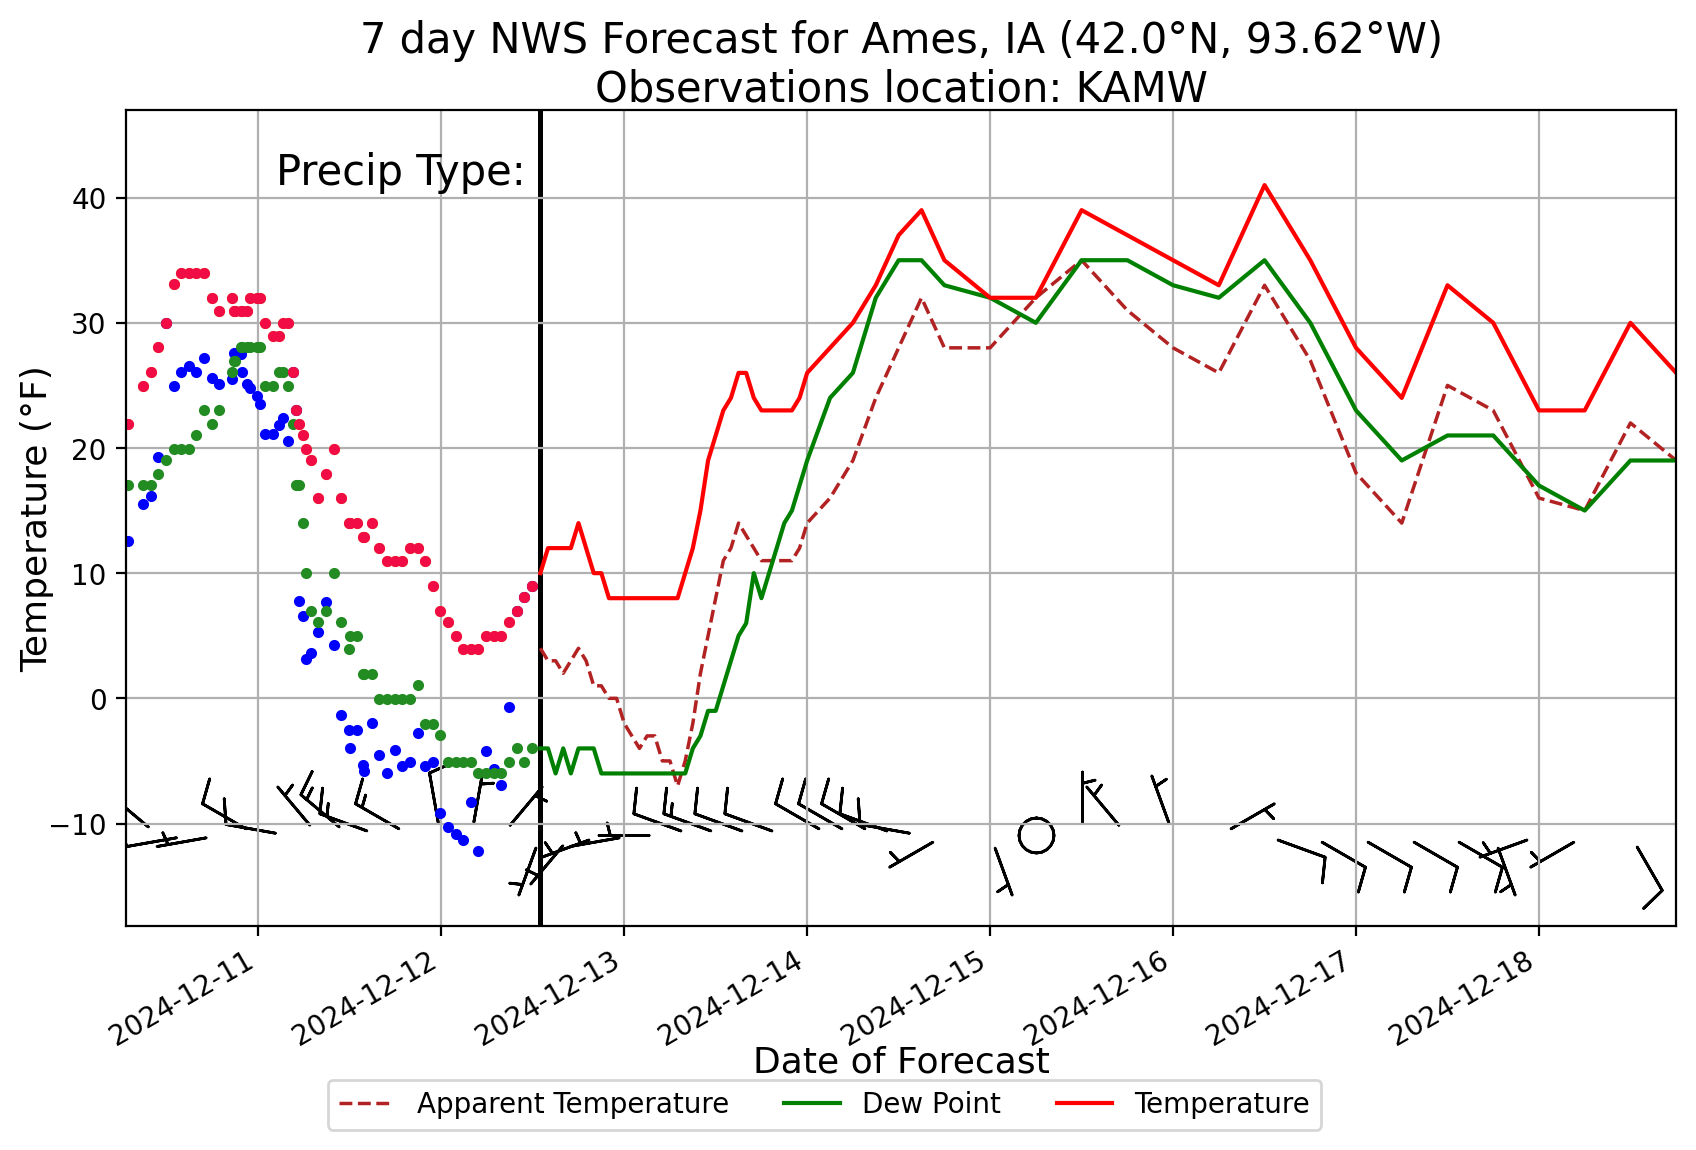

In [56]:
plt.rcParams["figure.dpi"] = 200
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the historical and forecasted temperatures, dew points, and heat indexes onto the graph.
# The order of plotting matters as the plots are layered with the last plot on top.
# Forecasted:
markerStyle = "."

#NWS forecasts:
if(forecastSuccess):
    ax.plot(dfForecast[timeName], dfForecast[heatIndexName], color='goldenrod', linewidth=1.25, label="Heat Index")
    ax.plot(dfForecast[timeName], dfForecast[windChillName], color='blue', linewidth=1.25, label="Wind Chill")
    ax.plot(dfForecast[timeName], dfForecast[dewpointName], color='green', linewidth=1.5, label="Dew Point")
    ax.plot(dfForecast[timeName], dfForecast[temperatureName], color='red', linewidth=1.5, label="Temperature")
# NDFD forecasts:
else:
    ax.plot(NDFDtimestamp, NDFDapparent, color='firebrick', linewidth=1.25, label="Apparent Temperature", linestyle='dashed')
    ax.plot(NDFDtimestamp, NDFDdews, color='green', linewidth=1.5, label="Dew Point")
    ax.plot(NDFDtimestamp, NDFDtemp, color='red', linewidth=1.5, label="Temperature")
# Historical:
ax.plot(dfHistory[timeName], dfHistory[heatIndexName], color='goldenrod', marker=markerStyle, linewidth=0)
ax.plot(dfHistory[timeName], dfHistory[windChillName], color='blue', marker=markerStyle, linewidth=0)
ax.plot(dfHistory[timeName], dfHistory[dewpointName], color='forestgreen', marker=markerStyle, linewidth=0)
ax.plot(dfHistory[timeName], dfHistory[temperatureName], color='xkcd:pinkish red', marker=markerStyle, linewidth=0)
#

#ax.scatter(x=dfHistory[timeName], y=dfHistory[dewpointName], color='forestgreen', marker=markerStyle, s=35)

# The bounds of the plot are set as 2 days before now and the ending timestamp, and the upper and lower temp bounds.
# The lower and upper bounds are the temperature mins and maxs, with a constant offset.
if(forecastSuccess):
    plt.axis([dateOffset - 2, dfForecast[timeName].iloc[-1], tempsLowerBound, tempsUpperBound])
else:
    plt.axis([dateOffset - 2, NDFDtimestamp[-1], tempsLowerBound, tempsUpperBound])
# Adjustable sizing for the size and location of the precip bar at the top of the chart.
# Also determines the location of the wind barbs. 
# This keeps everything consistent between cities with different amounts of daily variation.
axisHeight = ax.get_ylim()[1] - ax.get_ylim()[0]
barbPlacement = axisHeight / 9
pTypeBarSize = axisHeight / 1200
pTypePlacement = axisHeight / 10
pTextPlacement = axisHeight / 13

# Set the length of the wind barb.
barbLength = 6

# This draws the boxes for nighttime on the forecasted section of the plot.
# Whether or not it is considered night is not available from the station observations.
if(forecastSuccess):
    count1 = 0
    for i in dfForecast[timeName]:
        # The rectangle does not accept a datetime as a coordinate, so it has to be converted.
        # dateOffset is the initial offset, in days since 1970. The current index has to be divided by 24 since it represents hours.
        # The final addition of 6/24 accounts for the shift in time zones. Assumes Central.
        dateOffsetRect = dateOffset + (count1 / 24) + tzOffset
        
        # Draws dark boxes on the plot hour by hour to signify nighttime.
        if(dfForecast[nightName][count1] == False):
            ax.add_patch(patches.Rectangle((dateOffsetRect, -100), (1/24), 300, facecolor='gainsboro'))

        # Adds rectangles to chart showing if precipitation is falling during the period and which type if so.
        # Sets the height of the precipitation box to the chance of precipitation.
        ax.add_patch(patches.Rectangle((dateOffsetRect, tempsUpperBound-pTypePlacement), (1/24), pTypeBarSize*dfForecast[popName][count1], 
                                    facecolor=str(dfForecast[precipTypesName][count1])))
        
        count1 += 1

# This adds a line to the plot starting at the current time to show where the transition is from obs to forecast.
ax.add_patch(patches.Rectangle((dateOffset + tzOffset, -100), (1/36), 300, facecolor='black'))

# The wind barbs need to be graphed after the night boxes, otherwise they tend to get covered up.
# This is the number of hours between wind barbs (n).
hoursBetweenWind = 4
# This specifically plots every nth wind barb that is forecasted.
if(forecastSuccess):
    count2 = 0
    for j in dfForecast[timeName]:
        # Plots a wind barb every n units, which is equivalent to every 6 hours.
        if(count2 % hoursBetweenWind == 0):
            # Creates and gives the plot the location and size.
            stationplot = StationPlot(ax, dfForecast[timeName][count2], tempsLowerBound+barbPlacement, clip_on=True, length=barbLength)
            # Generate and draw the wind bard with the specified wind speeds in u and v.
            stationplot.plot_barb(dfForecast[windSpeedName][count2][0], dfForecast[windSpeedName][count2][1])
            
        count2 += 1
else:
    count2 = 0
    for j in NDFDwinds:
        # NDFD data is not hourly throughout the entire period.
        if(count2 <= 36):
            hoursBetweenWind = 4
        else:
            hoursBetweenWind = 1

        # Plots a wind barb every n hours.
        if(count2 % hoursBetweenWind == 0):
            # Creates and gives the plot the location and size.
            stationplot = StationPlot(ax, NDFDtimestamp[count2], tempsLowerBound+barbPlacement, clip_on=True, length=barbLength)
            # Generate and draw the wind bard with the specified wind speeds in u and v.
            stationplot.plot_barb(NDFDwinds[count2][0], NDFDwinds[count2][1])
            
        count2 += 1

# This section plots the historical wind data for the last few days.
# The timestamp is initialized to allow comparison. This allows the program to only plot the wind barbs every six hours.
# This is needed since stations do not observe at the same intervals, meaning the barbs would otherwise be closer
# or farther apart, depending on the station.
hoursBetweenWind = 4
timestampStored = dfHistory[timeName][0]
count3 = 0
for k in dfHistory[windSpeedName]:
    # If the difference in time since the last plotted barb is greater than six hours (21,600 seconds), plot a wind barb.
    if((timestampStored - dfHistory[timeName][count3]).total_seconds() >= hoursBetweenWind * 3600):
        stationplot = StationPlot(ax, dfHistory[timeName][count3], tempsLowerBound+barbPlacement, clip_on=True, length=barbLength)
        stationplot.plot_barb(dfHistory[windSpeedName][count3][0], dfHistory[windSpeedName][count3][1])

        # Reset the timestamp for comparison.
        timestampStored = dfHistory[timeName][count3]

    count3 += 1

# Set the text sizing. Used for the title and axis sizes.
title_kwargs = dict(ha='center', va='center', fontsize=15)
axis_kwargs = dict(ha='center', va='center', fontsize=13)

# Set the title and axes labels.
ax.set_title("7 day NWS Forecast for " + cityName + ", " + stateAbbr + " (" + str(lat) + "°N, " + str(abs(lon)) +"°W)" + \
             "\nObservations location: " + stationID, **title_kwargs)
ax.set_xlabel("Date of Forecast", **axis_kwargs)
ax.set_ylabel("Temperature (°F)", **axis_kwargs)

# This places the PType text on the graphic in the right place at the right size.
plt.text(float(dateOffset)-(12/24), tempsUpperBound-pTextPlacement, 'Precip Type:', **title_kwargs)

# Enable the grid on the plot.
ax.grid(True)

# Automatically format the dates to make them look much nicer.
fig.autofmt_xdate()

# Add a legend to the plot to make it clear what each product is.
leg = ax.legend(loc=(0.13, -0.25), ncol=4)

# Show the plot.
plt.show()

In [57]:
print(dfHistory.columns)

Index(['timestamp', 'temperature', 'dewpoint', 'relativeHumidity', 'heatIndex',
       'windChill', 'windSpeed', 'windDirection'],
      dtype='object')
